<a href="https://colab.research.google.com/github/preethisedigar/data_analytics_projects/blob/main/Student%2BPerformance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

In [ ]:
data = pd.read_csv("StudentsPerformance.csv")
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [ ]:
data.shape

(1000, 8)

In [ ]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
data['gender'].value_counts()

female    518
male      482
Name: gender, dtype: int64

In [ ]:
data['race/ethnicity'].value_counts()

group C    319
group D    262
group B    190
group E    140
group A     89
Name: race/ethnicity, dtype: int64

In [ ]:
data['parental level of education'].value_counts()

some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: parental level of education, dtype: int64

In [ ]:
data['lunch'].value_counts()

standard        645
free/reduced    355
Name: lunch, dtype: int64

In [ ]:
data['test preparation course'].value_counts()

none         642
completed    358
Name: test preparation course, dtype: int64

In [ ]:
data.groupby(['test preparation course'])['math score'].mean()

test preparation course
completed    69.695531
none         64.077882
Name: math score, dtype: float64

In [ ]:
data.groupby(['test preparation course'])['reading score'].mean()

test preparation course
completed    73.893855
none         66.534268
Name: reading score, dtype: float64

In [ ]:
data.groupby(['test preparation course'])['writing score'].mean()

test preparation course
completed    74.418994
none         64.504673
Name: writing score, dtype: float64

In [ ]:
result = data.groupby(['parental level of education'])['math score'].mean()
result = result.sort_values(ascending = False)
result

parental level of education
master's degree       69.745763
bachelor's degree     69.389831
associate's degree    67.882883
some college          67.128319
some high school      63.497207
high school           62.137755
Name: math score, dtype: float64

In [ ]:
pivot_table = data.pivot_table(index = 'parental level of education', columns = ['gender' ,'race/ethnicity'],
                              values = ['math score', 'reading score', 'writing score'], aggfunc = 'mean')
pivot_table.T

parental level of education          associate's degree  bachelor's degree  \
              gender race/ethnicity                                          
math score    female group A                  57.500000          51.666667   
                     group B                  62.652174          71.363636   
                     group C                  64.777778          65.807692   
                     group D                  63.375000          69.769231   
                     group E                  74.833333          74.800000   
              male   group A                  63.625000          72.333333   
                     group B                  70.500000          66.777778   
                     group C                  69.393939          72.500000   
                     group D                  71.500000          65.666667   
                     group E                  74.952381          78.750000   
reading score female group A                  70.166667          60.000000   
                     group B                  72.173913          80.000000   
                     group C                  73.866667          77.384615   
                     group D                  72.958333          78.000000   
                     group E                  80.111111          78.300000   
              male   group A                  64.750000          70.777778   
                     group B                  66.277778          64.333333   
                     group C                  67.393939          72.500000   
                     group D                  68.307692          63.333333   
                     group E                  68.428571          70.500000   
writing score female group A                  68.166667          61.666667   
                     group B                  71.695652          79.909091   
                     group C                  73.711111          78.884615   
                     group D                  73.333333          80.230769   
                     group E                  80.500000          78.000000   
              male   group A                  60.125000          70.555556   
                     group B                  63.833333          61.555556   
                     group C                  65.575758          70.357143   
                     group D                  66.653846          64.666667   
                     group E                  66.952381          72.125000   

parental level of education          high school  master's degree  \
              gender race/ethnicity                                 
math score    female group A           60.428571        50.000000   
                     group B           59.000000        70.800000   
                     group C           55.633333        62.000000   
                     group D           61.470588        66.600000   
                     group E           65.833333        72.428571   
              male   group A           60.454545        73.000000   
                     group B           60.900000        49.000000   
                     group C           65.558824        70.000000   
                     group D           63.740741        83.625000   
                     group E           76.700000        90.000000   
reading score female group A           69.857143        60.000000   
                     group B           69.035714        85.600000   
                     group C           65.966667        74.428571   
                     group D           68.705882        74.933333   
                     group E           70.166667        81.714286   
              male   group A           58.454545        74.000000   
                     group B           55.650000        53.000000   
                     group C           63.058824        68.250000   
                     group D           61.703704        81.375000   
                     group E           70.500000      

In [ ]:
pivot_table = data.pivot_table(index = 'parental level of education', columns = ['gender'],
                              values = ['math score', 'reading score', 'writing score'], aggfunc = 'mean')
pivot_table.T

parental level of education  associate's degree  bachelor's degree  \
              gender                                                 
math score    female                  65.250000          68.349206   
              male                    70.764151          70.581818   
reading score female                  74.120690          77.285714   
              male                    67.433962          68.090909   
writing score female                  74.000000          78.380952   
              male                    65.405660          67.654545   

parental level of education  high school  master's degree  some college  \
              gender                                                      
math score    female           59.351064        66.500000     65.406780   
              male             64.705882        74.826087     69.009259   
reading score female           68.202128        76.805556     73.550847   
              male             61.480392        73.130435     64.990741   
writing score female           66.691489        77.638889     74.050847   
              male             58.539216        72.608696     63.148148   

parental level of education  some high school  
              gender                           
math score    female                59.296703  
              male                  67.840909  
reading score female                69.109890  
              male                  64.693182  
writing score female                68.285714  
              male                  61.375000

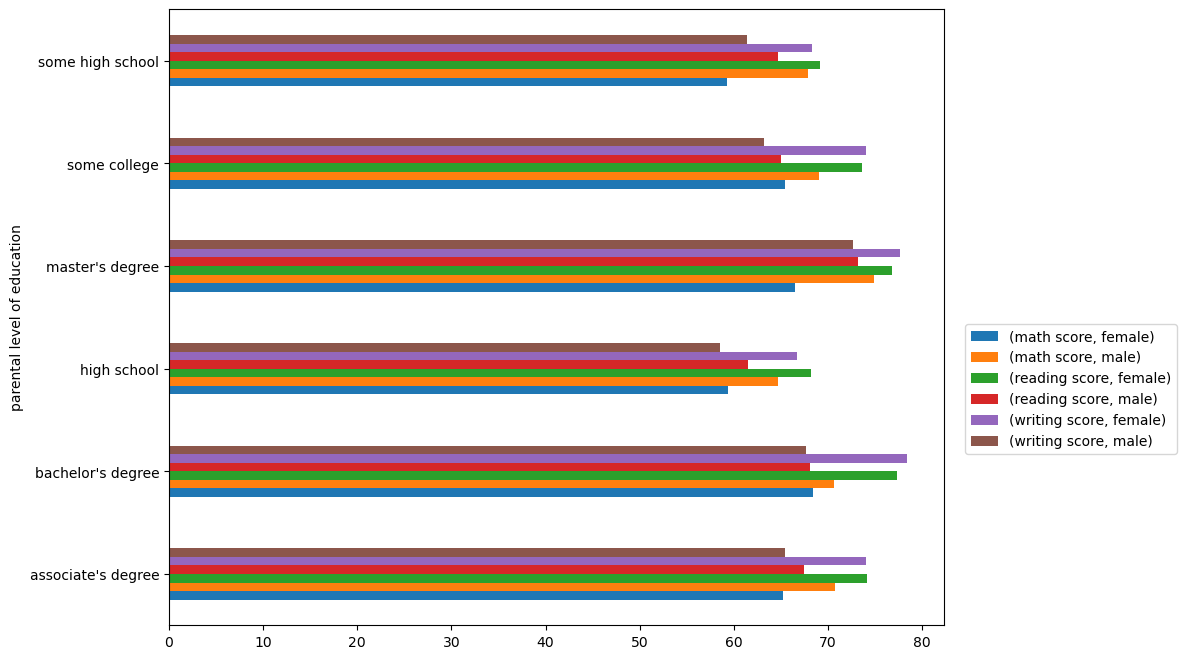

In [ ]:
pivot_table.plot(kind = 'barh', figsize = [10,8])
plt.legend(bbox_to_anchor = (1.31, 0.5))
plt.show()

In [ ]:
pivot_table = data.pivot_table(columns = ['gender'],
                              values = ['math score', 'reading score', 'writing score'], aggfunc = 'mean')
pivot_table.T

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


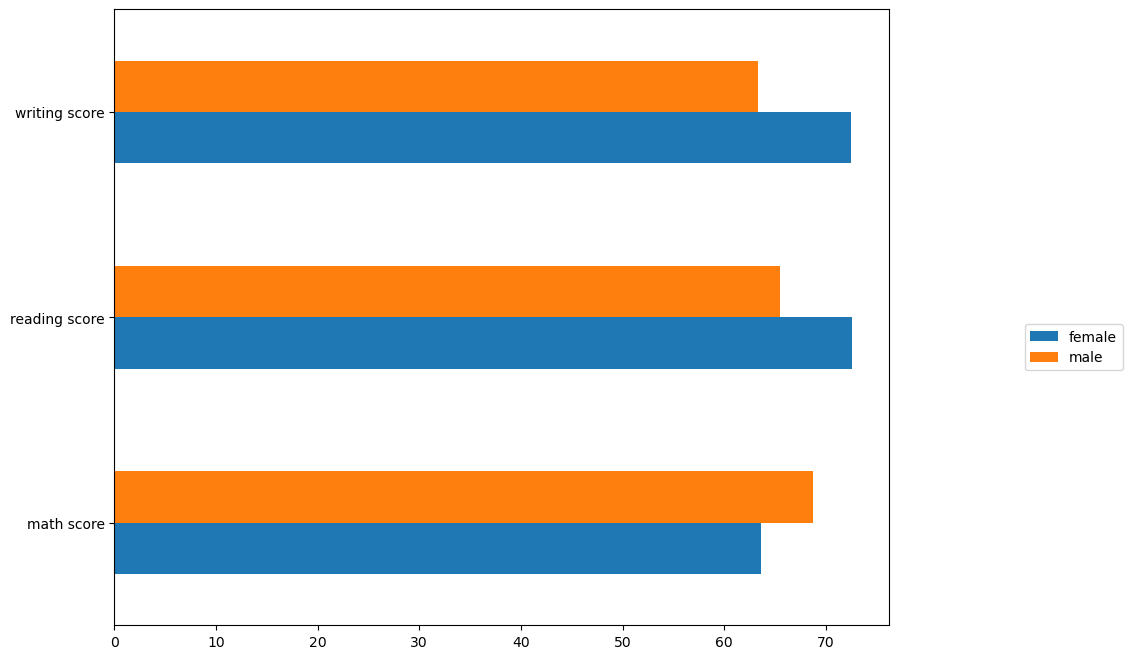

In [ ]:
pivot_table.plot(kind = 'barh', figsize = [10,8])
plt.legend(bbox_to_anchor = (1.31, 0.5))
plt.show()

In [ ]:
pivot_table = data.pivot_table(columns = ['race/ethnicity'],
                              values = ['math score', 'reading score', 'writing score'], aggfunc = 'mean')
pivot_table.T

,math score,reading score,writing score
race/ethnicity,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143


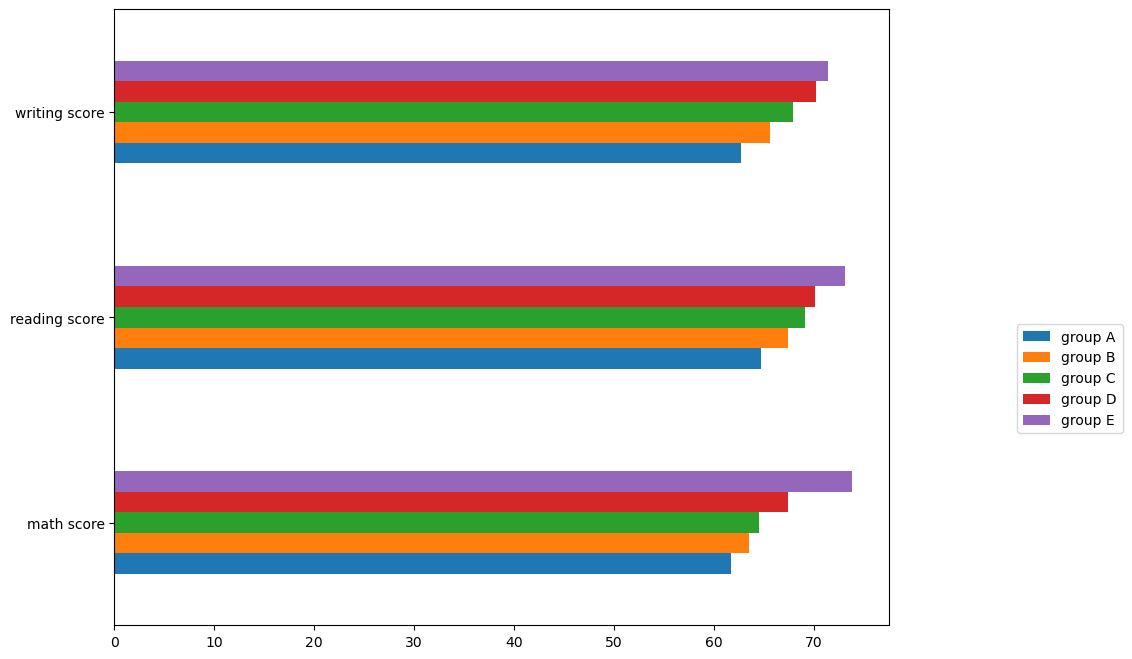

In [ ]:
pivot_table.plot(kind = 'barh', figsize = [10,8])
plt.legend(bbox_to_anchor = (1.31, 0.5))
plt.show()

In [ ]:
pivot_table = data.pivot_table(columns = ['test preparation course'],
                              values = ['math score', 'reading score', 'writing score'], aggfunc = 'mean')
pivot_table.T

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


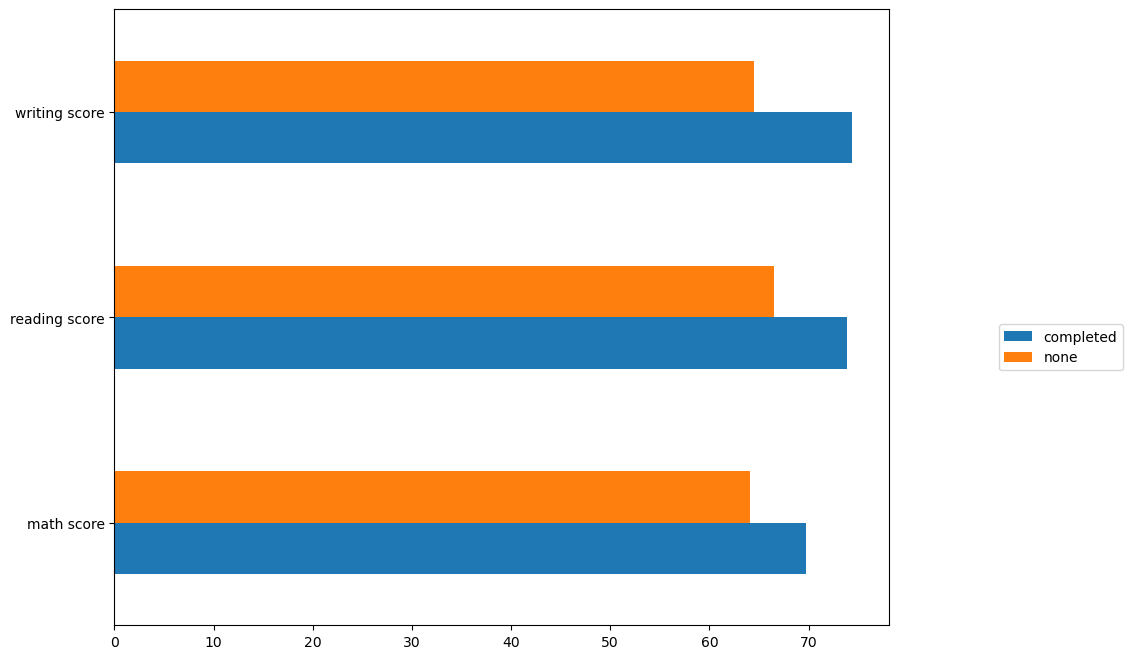

In [ ]:
pivot_table.plot(kind = 'barh', figsize = [10,8])
plt.legend(bbox_to_anchor = (1.31, 0.5))
plt.show()

Here are the key inferences based on common trends observed in the **Student Performance dataset**:

---

### **1. Influence of Parental Education**
   - Students whose parents have higher levels of education tend to perform better in all subjects.
   - This indicates a positive correlation between parental education and student performance.

### **2. Effect of Test Preparation**
   - Students who completed a test preparation course usually score higher than those who did not.
   - This suggests that structured preparation improves academic outcomes.

### **3. Socio-Economic Impact**
   - Students receiving free/reduced-price lunch often score lower than those who don’t.
   - This implies that socio-economic factors may influence academic performance.

### **4. Gender-Based Differences**
   - Female students generally perform better in Reading and Writing, while male students often excel in Math.
   - This highlights potential gender-specific strengths in subject areas.

### **5. Subject Consistency**
   - Students who excel in one subject (e.g., Math) are likely to perform well in others (e.g., Reading and Writing), indicating overall aptitude or learning consistency.

### **6. Key Predictors**
   - Factors such as parental education, lunch type, and test preparation are strong predictors of student performance.
   - Interventions targeting these areas could lead to better outcomes for low-performing students.

---

### **Actionable Insights**
   - Encourage more students to take test preparation courses.
   - Provide additional resources and support for students from lower socio-economic backgrounds.
   - Design gender-sensitive programs to bridge performance gaps in specific subjects.
